# Neural Networks

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chattopadhyayA/ml_pursue2026/blob/master/content_nb/06_NN_basic.ipynb)

#### Human Brains are amazing can we mimic that??

```{figure} images/brain_compu.png
:align: center
:width: 650px
```

- An individual neuron can either fire or not depending on the level of input stimuli. So mathematically 
one can think of neurons as some function which is zero below a minimum value of input.<br>

![alt text](images/neuron.png "Title")

- Output of a single neuron depends on the output of the neurons that are connected with it,
each with a varied strength of connection. <br>


![alt text](images/neurons.png "Title")

### Activation functions

Activation functions are mathematical functions that can mimic the behavious of a "biological neuron", where the notion of input stimuli is replaced with a input variable. Because of some reasons, that would be clarified below, the activation functions needs to be smooth (or differentiable). Although **Re**ctified **L**inear **U**nit and step functions are not smooth activation functions, but they are still commonly used in neural networks. Their non-smoothness doesn't prevent them from being effective activation functions, though it can have some implications for training. 

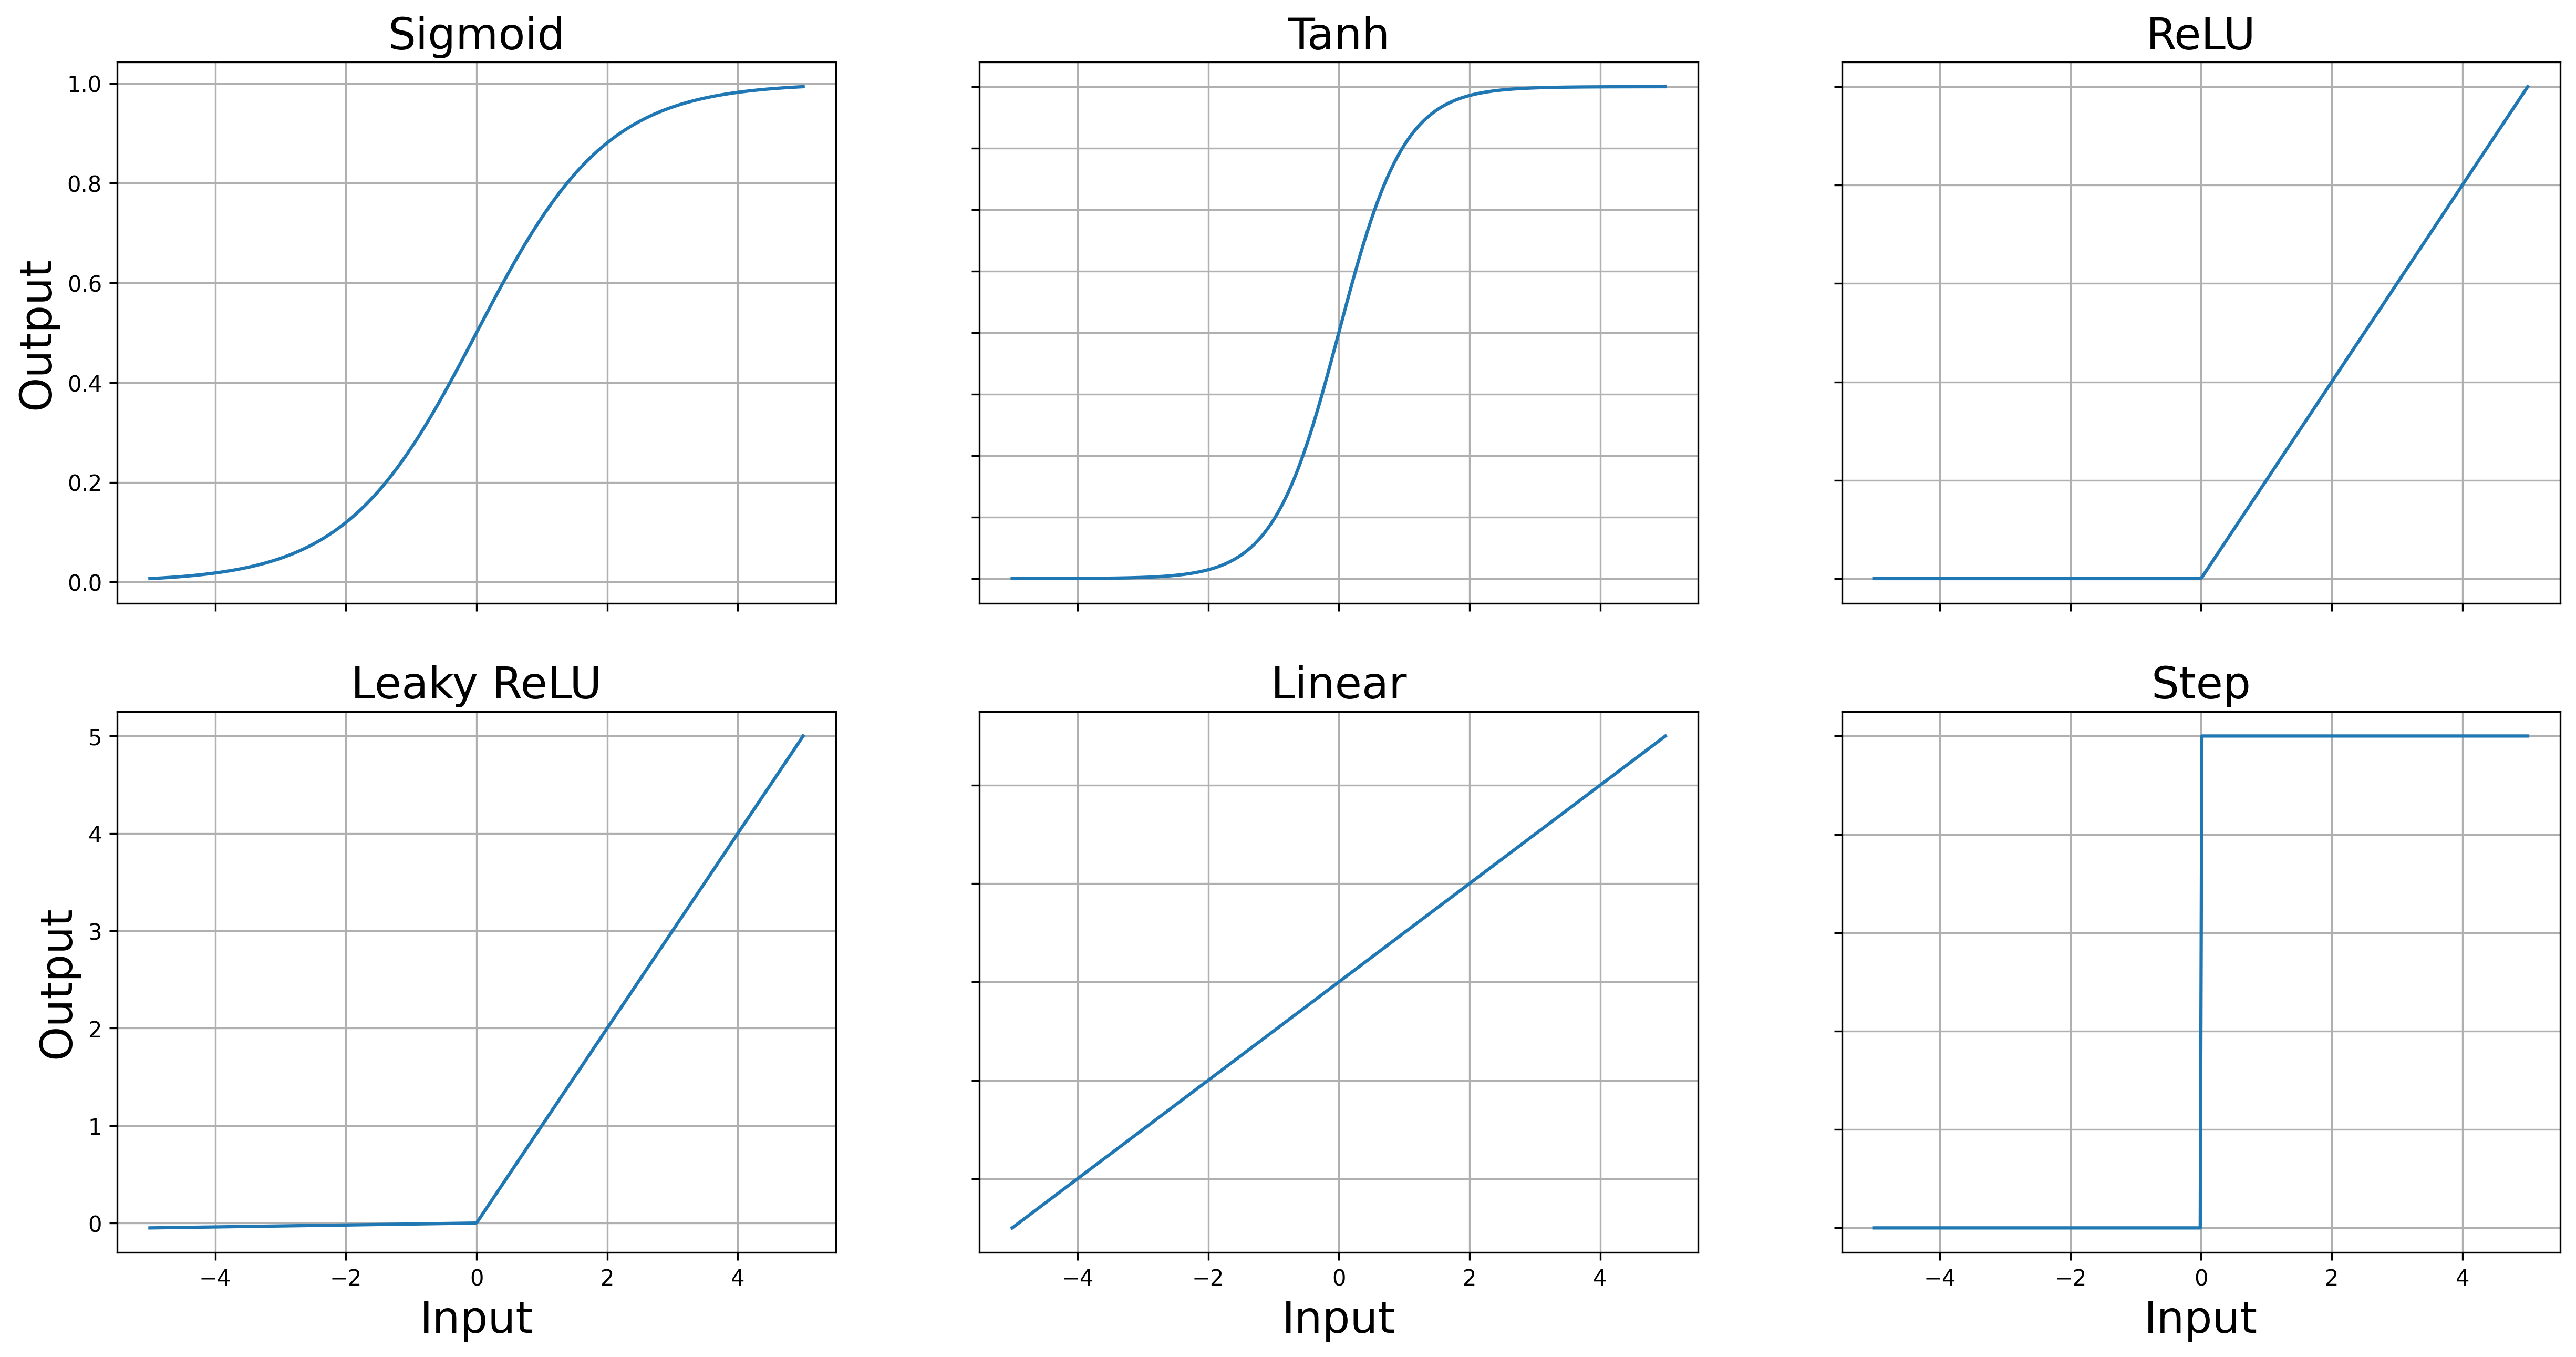

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Define the activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

def linear(x):
    return x

def step(x):
    return np.where(x >= 0, 1, 0)

# Generate x values
x = np.linspace(-5, 5, 400)

# Calculate y values for each activation function
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)
y_leaky_relu = leaky_relu(x)
y_linear = linear(x)
y_step = step(x)

# Plotting
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

plt.rc('axes', titlesize=20)

axs[0,0].plot(x, y_sigmoid, label='Sigmoid')
axs[0,0].set_title('Sigmoid')
axs[0,1].plot(x, y_tanh, label='Tanh')
axs[0,1].set_title('Tanh')
axs[0,2].plot(x, y_relu, label='ReLU')
axs[0,2].set_title('ReLU')
axs[1,0].plot(x, y_leaky_relu, label='Leaky ReLU')
axs[1,0].set_title('Leaky ReLU')
axs[1,1].plot(x, y_linear, label='Linear')
axs[1,1].set_title('Linear')
axs[1,2].plot(x, y_step, label='Step')
axs[1,2].set_title('Step')


for ax in axs.flat:
    x_label = ax.set_xlabel('Input')
    y_label = ax.set_ylabel('Output')
    x_label.set_size(20) 
    y_label.set_size(20)  
    ax.grid(True)

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()


## Neural Networks

- For each neuron, we define three properties
    1. **Weight:** between each two connected neurons weight defines what is the importance of the previous neuron to the next one.
    2. **Bias:** Offset or bias is a intrinsic property/parameter of each of the neuron.
    3. **Activation function:** Input of each neuron is defined as the weighted sum $z=\sum_j w_j y_j +b$. If the activation function is $f$ for the neuron then output would be $f(z)$.


```{figure} images/sing_neur.png
---
height: 200px
name:   sing_neur
align:  center
---
"Weights and bias of a sigle output neuron"
```


```{figure} images/nnetwork.png
---
height: 250px
name:   nnetwork
align:  center
---
"A neural network"
```

## Implementation

There are several popular python packages for implementing neural networks like **Tensorflow**, **Pytorch** etc. In this course we will only focus on **Pytorch**. In all the packages, the core ideas remains the same

1. **Feed-Forward**
    - For each layer the input $a$ ($a=x$ for the first layer) is multiplied by weights $W$, added to biases $b$, then passed through as activation function $f$. Therefore, for the $l^{th}$ layer and $i^{th}$ neuron we have the output
  
    $$
    z^{l}_i = \sum_{j=1}^{h_l} f(w^{(l,l-1)}_{ij}z^{l-1}_j+b_{i}^{l})
    $$

    where $h_l$ is the number of hidden nodes at the $l^{th}$ layer. Note that here we are using $h_0=len(x)$.
    - Note that here the network/model parameters $\theta$ includes all weights and biases as a whole.
    - Output propagates from input layer through hidden layers to the output.



2. **Back-Propagation**
    - Compute loss $\mathcal{L}(\hat{y},y;\theta)$ where $\hat{y}$ is the network output and $y$ is the true output.
    - Use the chain rule to compute $\frac{\partial \mathcal{L}}{\partial W_{ij}^{(l,l-1)}}$ and $\frac{\partial \mathcal{L}}{\partial b_i^{l}}$ for each layer $l$, propagating the error backward.



3. **Gradient Descent**
    - Update each parameter $\theta \in {w,b}$ by
    $$
    \theta \leftarrow \theta - \alpha \frac{\partial \mathcal{L}}{\partial \theta}
    $$
    where $\alpha$ is the learning rate.


## <span style="color:maroon"> A neural network from scratch </span>

In this case we are writing a neural network just using *numpy*. and observing the outputs using *matplotlib*. The first job is always to call required libraries

In [78]:
import numpy as np
import matplotlib.pyplot as plt # for plotting
import matplotlib
matplotlib.rcParams['figure.dpi']=300

In [79]:
# calculate f(z) and f'(z)

def net_f_df_sigmoid(z):
    """
    Sigmoid activation and its derivative.

    Input:
        z = weighted input to a neuron

    Output:
        val = sigmoid(z)
        derivative = d(sigmoid)/dz

    We return both because the derivative is needed during backpropagation.
    """
    val = 1/(1 + np.exp(-z)) # sigmoid(z)
    return(val,np.exp(-z)*(val**2)) # return both f and f'


def net_f_df_relu(z):
    """
    ReLU activation and its derivative.

    ReLU(z) = z if z > 0, and 0 otherwise.

    Its derivative is 1 for z > 0 and 0 for z < 0.
    At z = 0 it is not differentiable, but in practice we choose one value.
    """
    val=z*(z>0)
    return(val,z>0) # return both f and f'

In [80]:
def forward_step(y,w,b):
    """
    One forward step from one layer to the next.

    y: activations coming from the previous layer
    w: weights connecting previous layer to next layer
    b: bias of the next layer

    The neuron first computes the weighted sum z = y w + b,
    then applies an activation function.
    """
    z=np.dot(y,w)+b # weighted sum
    return(net_f_df_relu(z)) # activation value and derivative

In [81]:
def apply_net(y_in):
    """
    Full forward pass through the network.

    This function sends the input through all layers of the network.
    We also store intermediate activations and derivatives because
    backpropagation needs them later.
    """
    global Weights, Biases, NumLayers # Try not using global by making all of these as a single class
    global y_layer, df_layer # for storing y-values and df/dz values
    
    y = y_in # start with input values
    y_layer[0] = y
    for j in range(NumLayers): # loop through all layers
        # j=0 corresponds to the first layer above the input
        y,df = forward_step(y,Weights[j],Biases[j]) # one layer update
        df_layer[j] = df # store f'(z), needed later in backprop
        y_layer[j+1] = y # store activation value, also needed later
    return(y)

In [82]:
def backward_step(delta,w,df):
    """
    Propagate the error signal one layer backwards.

    delta measures how much the current layer contributed to the loss.
    Multiplying by the transposed weight matrix sends this information
    back to the previous layer. Multiplying by df applies the chain rule.
    """
    return( np.dot(delta,np.transpose(w))*df )


def backprop(y_target):
    """
    One backward pass through the network.

    This computes gradients of the loss with respect to all weights and biases.
    These gradients are stored in dw_layer and db_layer.
    """
    global y_layer, df_layer, Weights, Biases, NumLayers
    global dw_layer, db_layer # dCost/dw and dCost/db 
    global batchsize
    
    # Error at the output layer.
    # For MSE loss, the first factor is predicted - target.
    # The second factor comes from the derivative of the activation function.
    delta = (y_layer[-1]-y_target)*df_layer[-1]

    # Gradients for the last layer.
    dw_layer[-1] = np.dot(np.transpose(y_layer[-2]),delta)/batchsize
    db_layer[-1] = delta.sum(0)/batchsize

    # Move backwards through the remaining layers.
    for j in range(NumLayers-1):
        delta = backward_step(delta,Weights[-1-j],df_layer[-2-j])
        dw_layer[-2-j] = np.dot(np.transpose(y_layer[-3-j]),delta)
        db_layer[-2-j] = delta.sum(0)/batchsize

In [83]:
def gradient_step(eta):
    """
    Update weights and biases using gradient descent.

    eta is the learning rate.
    Larger eta means bigger steps, but too large values can make training unstable.
    """
    global dw_layer, db_layer, Weights, Biases
    
    for j in range(NumLayers):
        Weights[j]-=eta*dw_layer[j]
        Biases[j]-=eta*db_layer[j]

In [84]:
def train_net(y_in,y_target,eta):
    """
    One complete training step on one batch.

    The order is:
        1. forward pass
        2. backward pass
        3. gradient descent update
        4. return the loss/cost
    """
    global y_out_result
    
    y_out_result = apply_net(y_in)
    backprop(y_target)
    gradient_step(eta)
    cost = ((y_target-y_out_result)**2).sum()/batchsize
    return(cost)

- Now we are ready to test this above network. let us first define our own function that we want the network to learn

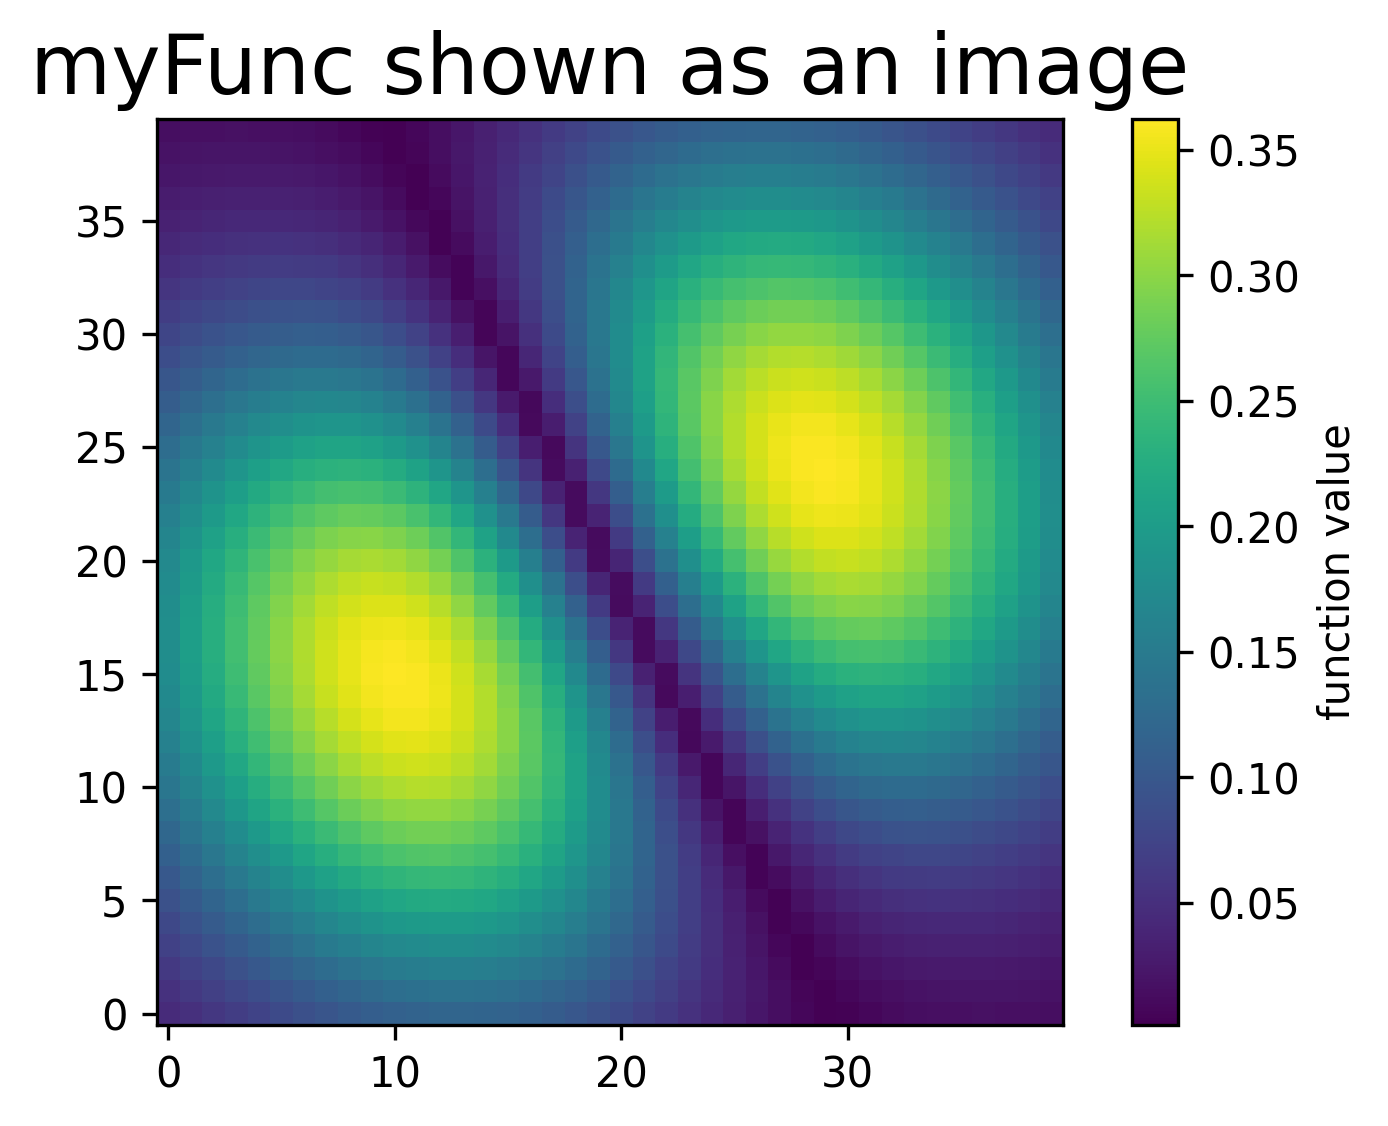

In [85]:
def myFunc(x0,x1):
    """
    A simple two-variable function for the NumPy network to learn.

    The input is a point (x0, x1) in the plane.
    The output is one number.

    We choose a function with a localized bump-like structure so that
    students can visually see whether the network is learning the shape.
    """
    r2=x0**2+x1**2
    return(np.exp(-7*r2)*np.abs(x1+2*x0))

xrange = np.linspace(-0.5,0.5,40)
X0,X1 = np.meshgrid(xrange,xrange)
plt.imshow(myFunc(X0,X1),interpolation='nearest',origin='lower') # Only shows array indices not the actual range
plt.title("myFunc shown as an image")
plt.colorbar(label="function value")
plt.show()

In [86]:
def make_batch():
    """
    Create one random training batch.

    Each training example is a random point (x0, x1) in the square [-0.5, 0.5].
    The target is the value of myFunc(x0, x1).

    This is the NumPy version of what a DataLoader usually does for us in PyTorch.
    """
    global batchsize

    inputs = np.random.uniform(low=-0.5,high=+0.5,size=[batchsize,2])
    targets = np.zeros([batchsize,1]) # must have right dimensions
    targets[:,0] = myFunc(inputs[:,0],inputs[:,1])
    return(inputs,targets)

In [87]:
# Let us first create the network.

# NumLayers counts the layers that have trainable weights.
# It does not count the input layer, but it does count the output layer.
NumLayers = 2

# LayerSizes tells us the size of each layer.
# Here: 2 input features -> 100 hidden neurons -> 1 output value.
LayerSizes = [2,100,1]

# Initialize random weights and zero biases for all layers.
# Small random weights help break symmetry between neurons.
Weights = [np.random.uniform(low=-0.1,high=+0.1,size=[ LayerSizes[j],LayerSizes[j+1] ]) for j in range(NumLayers)]
Biases = [np.zeros(LayerSizes[j+1]) for j in range(NumLayers)]

# Batch size = number of examples used in one training update.
batchsize=100

# Helper arrays for the forward and backward passes.
# y_layer stores activations, df_layer stores activation derivatives,
# and dw_layer/db_layer store gradients.
y_layer = [np.zeros([batchsize,LayerSizes[j]]) for j in range(NumLayers+1)]
df_layer = [np.zeros([batchsize,LayerSizes[j+1]]) for j in range(NumLayers)]
dw_layer = [np.zeros([LayerSizes[j],LayerSizes[j+1]]) for j in range(NumLayers)]
db_layer = [np.zeros(LayerSizes[j+1]) for j in range(NumLayers)]

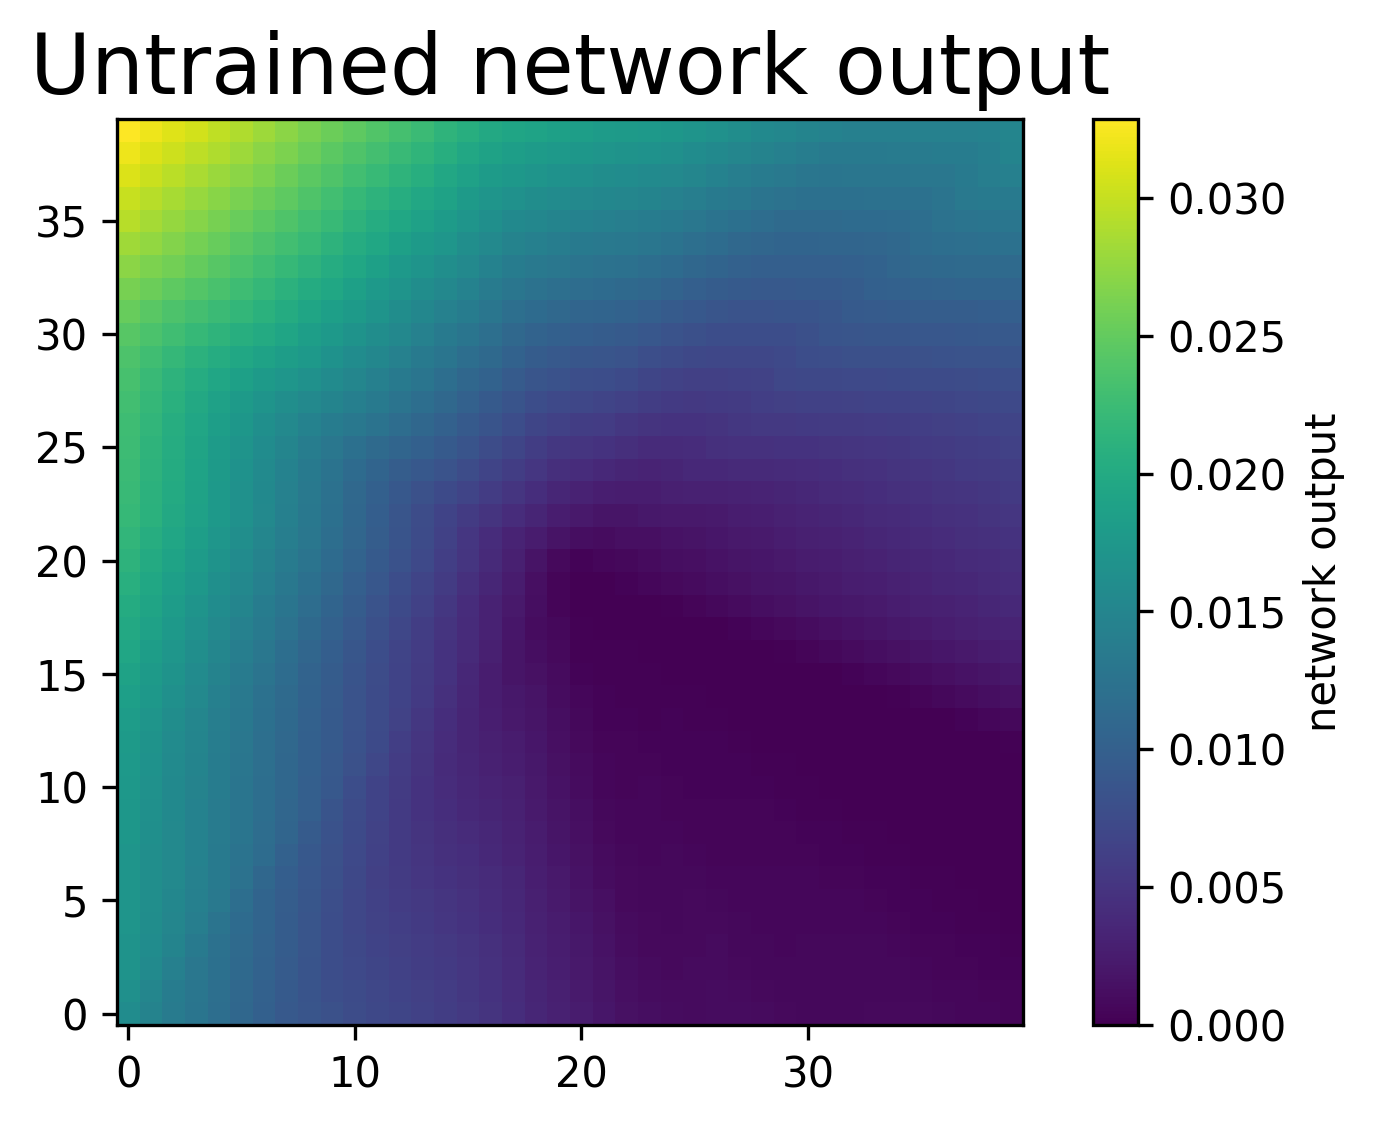

In [88]:
# First we try without training the network.
# Since the weights are random, the output should not look like the target function yet.

def apply_net_simple(y_in):
    """Forward pass used only for plotting/testing, without storing backprop information."""
    y = y_in
    y_layer[0] = y
    for j in range(NumLayers):
        y,df = forward_step(y,Weights[j],Biases[j])
    return(y)

# Choose a grid of points in the 2D plane.
test_batchsize = np.shape(X0)[0]*np.shape(X0)[1]
testsample = np.zeros([test_batchsize,2])
testsample[:,0] = X0.flatten()
testsample[:,1] = X1.flatten()

# Evaluate the untrained network on all grid points.
testoutput = apply_net_simple(testsample)
myim = plt.imshow(np.reshape(testoutput,np.shape(X0)),origin='lower',interpolation='none')
plt.title("Untrained network output")
plt.colorbar(label="network output")
plt.show()

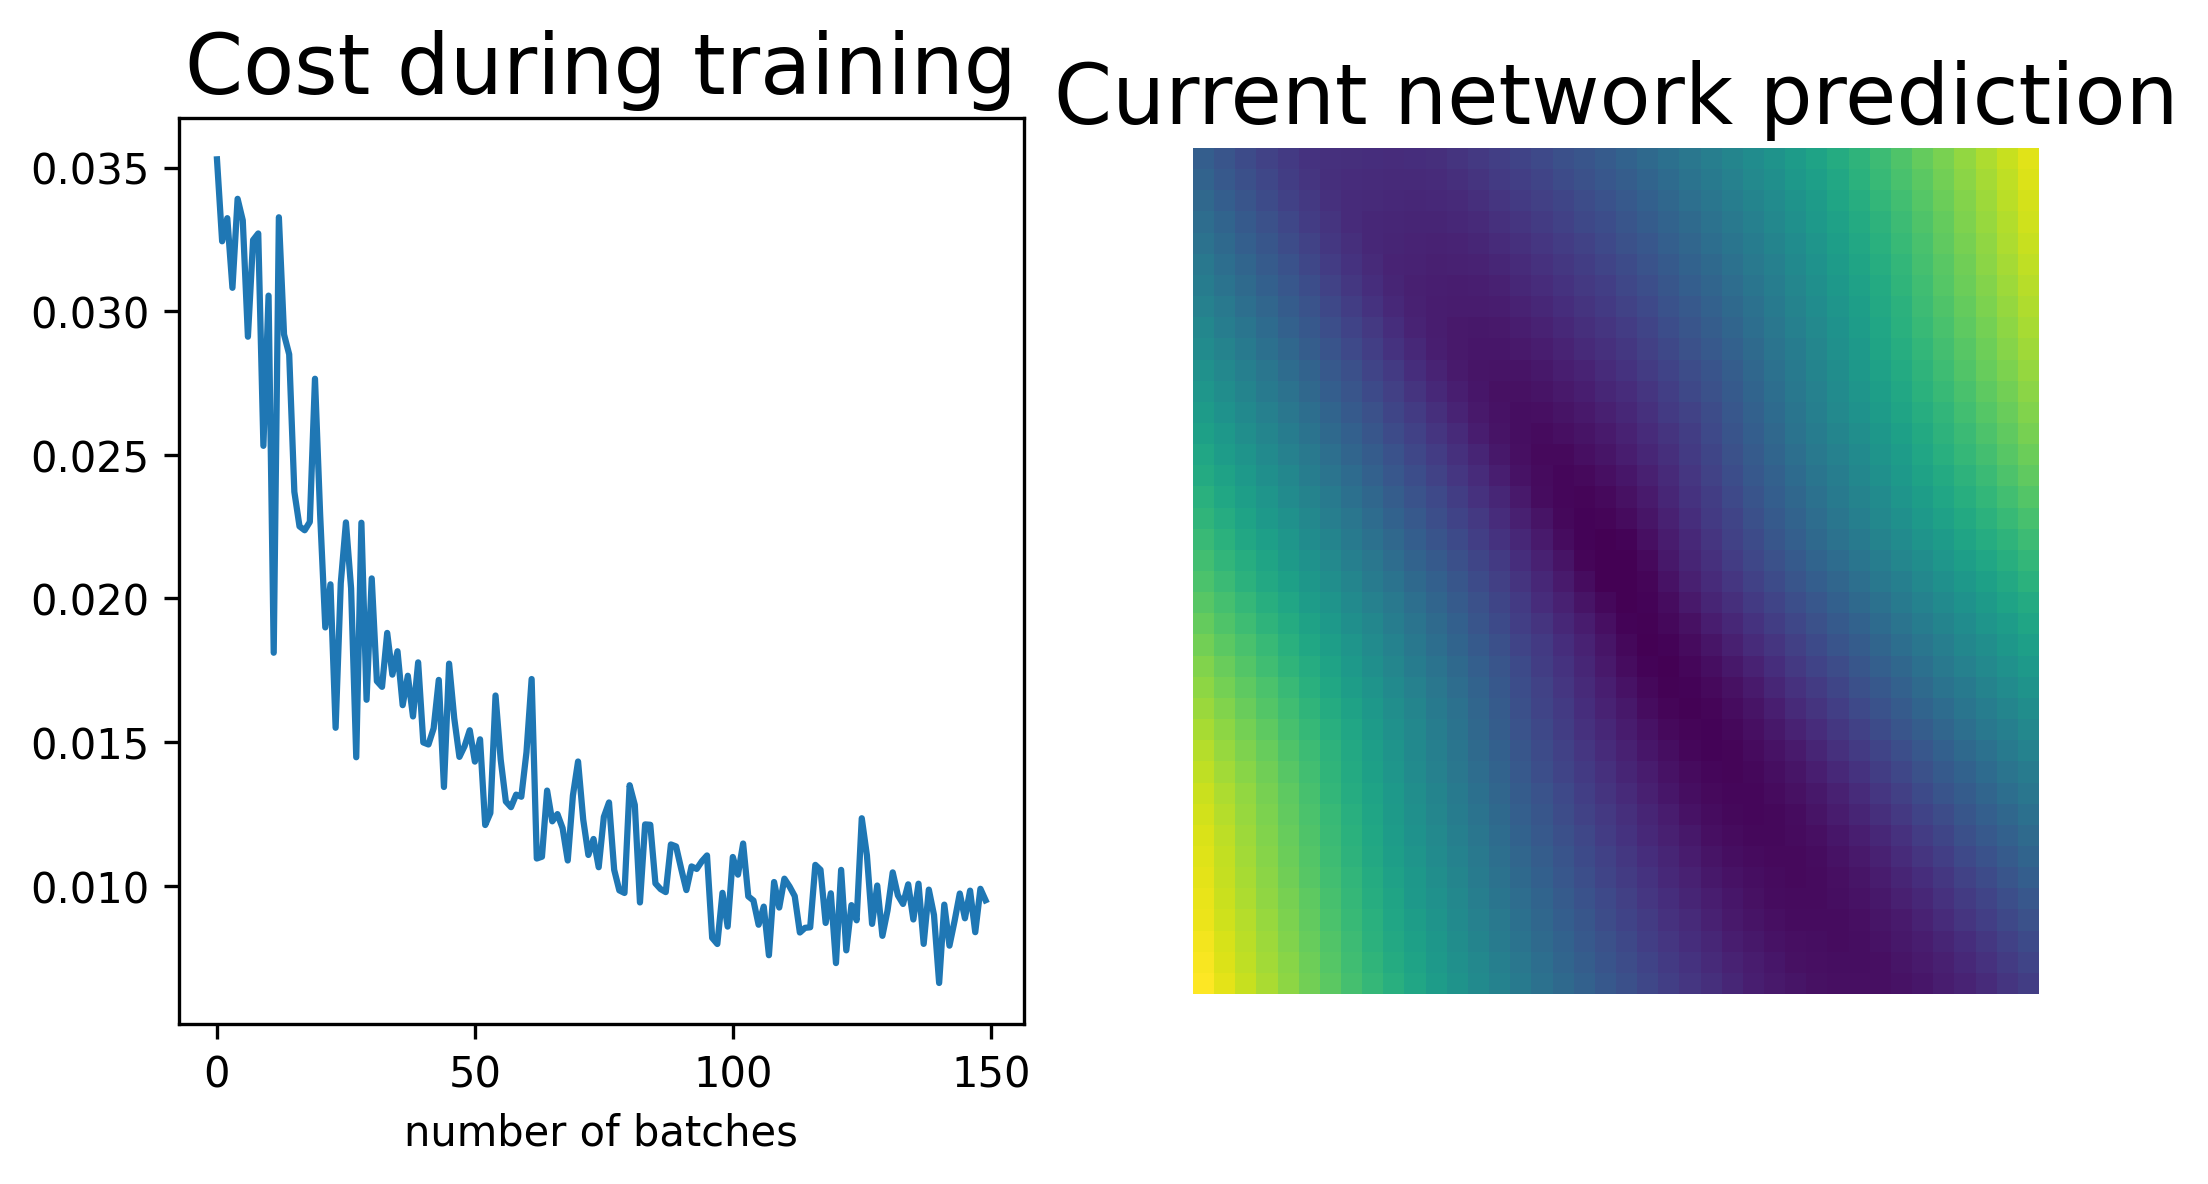

In [89]:
# Import functions for updating display.
# This creates a simple animation during training.
from IPython.display import clear_output
from time import sleep

eta = 0.01 # learning rate
nsteps = 150

costs = np.zeros(nsteps)
for j in range(nsteps):
    clear_output(wait = True)
    fig,ax = plt.subplots(ncols=2,nrows=1,figsize=(8,4)) # prepare figure
    ax[1].axis('off') # no axes
    
    # Create a fresh random batch.
    y_in,y_target = make_batch()

    # Train the network on this batch.
    costs[j] = train_net(y_in,y_target,eta)

    # Evaluate the updated network on the full grid for visualization.
    testoutput = apply_net_simple(testsample)
    
    img = ax[1].imshow(np.reshape(testoutput,np.shape(X0)),interpolation='nearest',origin='lower')
    ax[0].plot(costs)
    
    ax[0].set_title("Cost during training")
    ax[0].set_xlabel("number of batches")
    ax[1].set_title("Current network prediction")
    plt.show()
    sleep(0.1)

### Using PyTorch

We will now implement the same training idea in **PyTorch**.

Instead of asking the network to learn a completely clean curve, we will give it **noisy training data** sampled from a simple underlying function,

$$
y_{\rm true}=\sin(2x)+0.3x, \qquad x\in[-3,3].
$$

The noise is useful pedagogically: it lets us clearly see the difference between **under-fitting**, **over-fitting**, and **early stopping**.

- A model that is too simple cannot follow the main trend.
- A model that is too flexible and trained too long may start following the noise.
- Early stopping tries to stop training when validation performance stops improving.

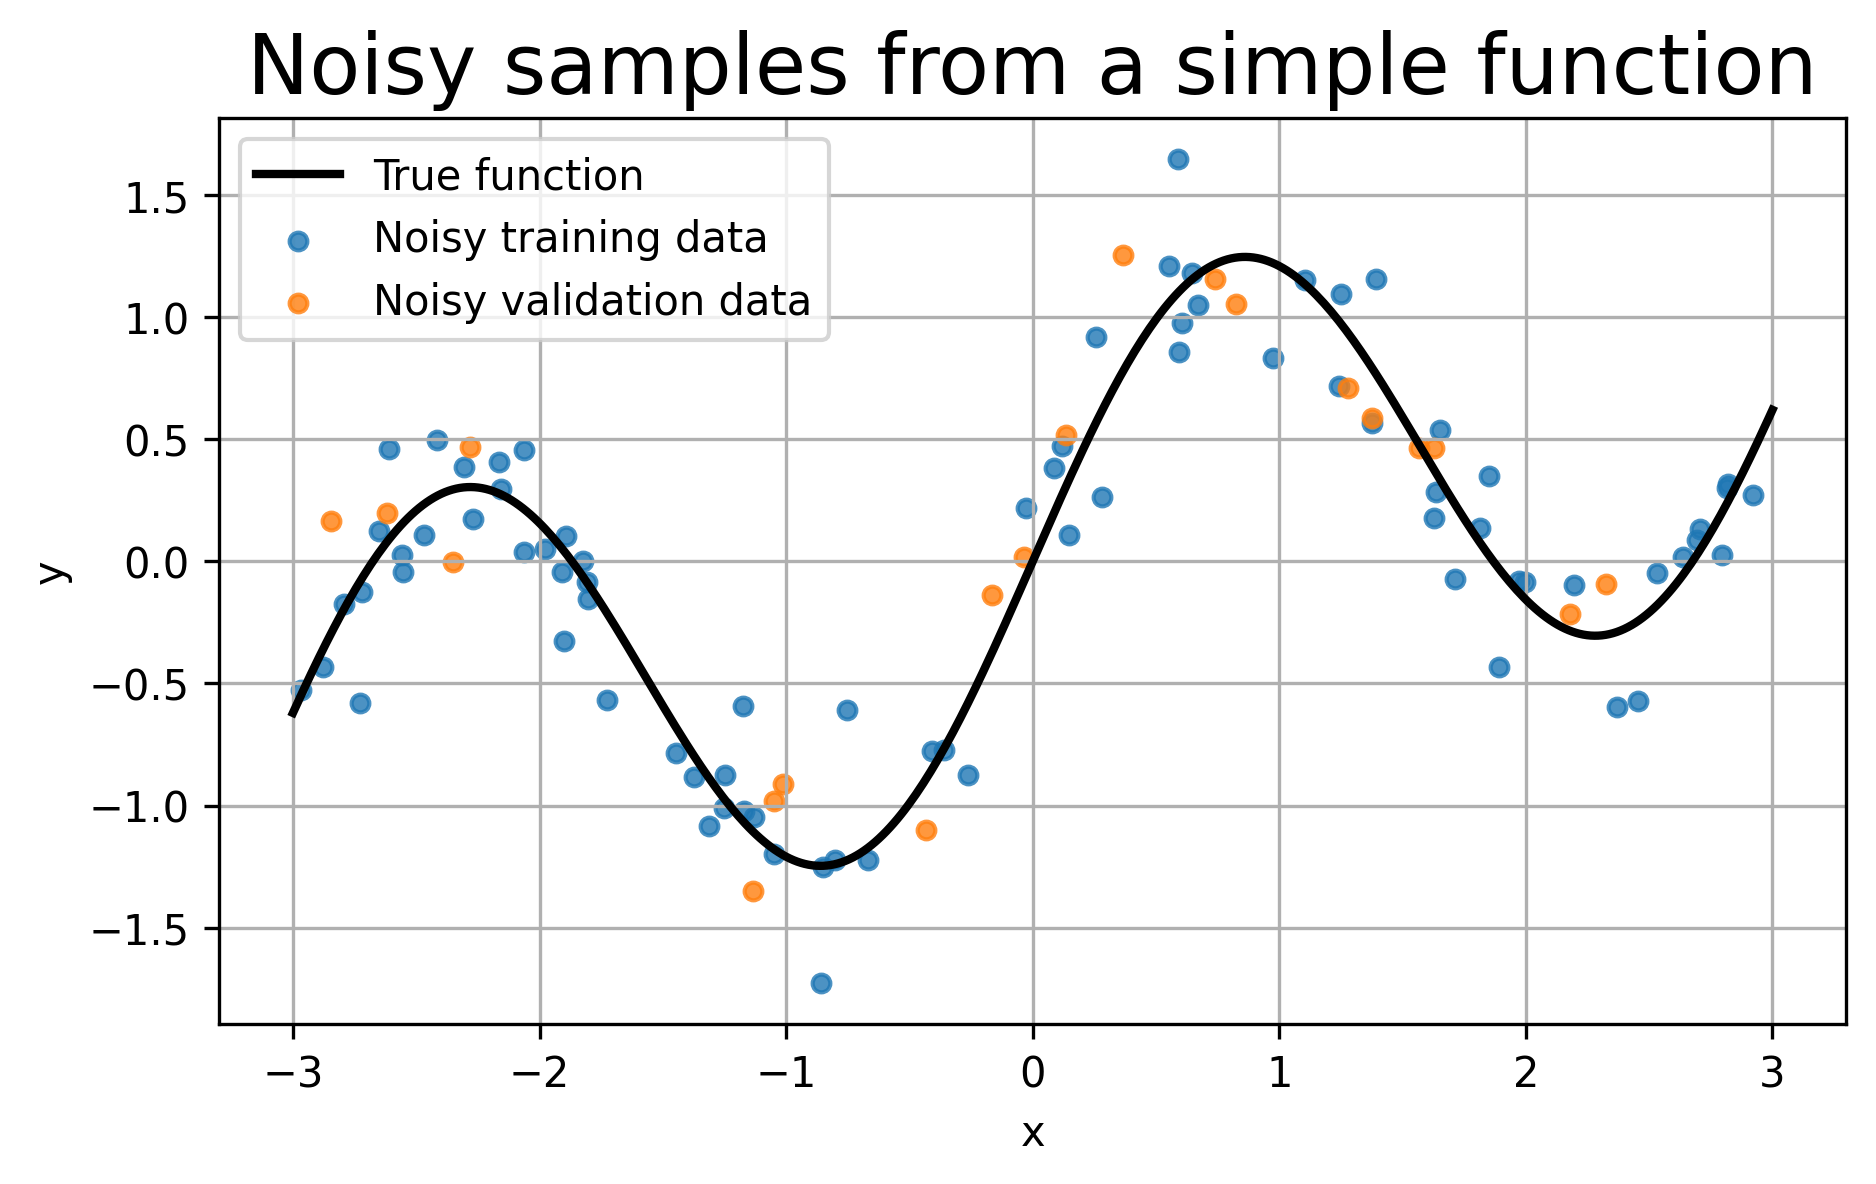

In [90]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchinfo import summary
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Fix the random seeds for reproducibility.
np.random.seed(42)
torch.manual_seed(42)


def true_function(x):
    """
    The hidden function that generates the clean signal.

    The network will not directly see this function.
    It will only see noisy samples from it.
    """
    return np.sin(2*x) + 0.3*x


# Number of points used for training and validation.
N_train = 80
N_val = 20

# Random x-values for training and validation.
# Sorting is only done to make plots easier to read.
X_train_np = np.sort(np.random.uniform(-3, 3, size=(N_train, 1)), axis=0)
X_val_np   = np.sort(np.random.uniform(-3, 3, size=(N_val, 1)), axis=0)

# Noise level in the observed data.
noise_level = 0.25

# Clean target values.
Y_train_clean = true_function(X_train_np)
Y_val_clean   = true_function(X_val_np)

# Noisy observed values.
# This imitates the fact that real data rarely sit perfectly on the true curve.
Y_train_np = Y_train_clean + noise_level*np.random.randn(N_train, 1)
Y_val_np   = Y_val_clean   + noise_level*np.random.randn(N_val, 1)

# A dense grid used only for drawing the true curve and the model prediction.
X_plot_np = np.linspace(-3, 3, 400).reshape(-1, 1)
Y_plot_np = true_function(X_plot_np)

# Plot the data and the hidden true function.
plt.figure(figsize=(7,4))
plt.plot(X_plot_np, Y_plot_np, 'k-', linewidth=2, label='True function')
plt.scatter(X_train_np, Y_train_np, s=18, alpha=0.8, label='Noisy training data')
plt.scatter(X_val_np, Y_val_np, s=18, alpha=0.8, label='Noisy validation data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Noisy samples from a simple function')
plt.legend()
plt.grid(True)
plt.show()


In [91]:
# Convert NumPy arrays to PyTorch tensors.
# PyTorch models expect tensors, usually in float32 precision.
X_train = torch.from_numpy(X_train_np).float()
Y_train = torch.from_numpy(Y_train_np).float()
X_val   = torch.from_numpy(X_val_np).float()
Y_val   = torch.from_numpy(Y_val_np).float()
X_plot  = torch.from_numpy(X_plot_np).float()

# TensorDataset simply pairs inputs and targets together.
train_set = TensorDataset(X_train, Y_train)
val_set   = TensorDataset(X_val, Y_val)

# DataLoader gives mini-batches during training.
# shuffle=True means each epoch sees the training examples in a new random order.
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)


#### Defining the Model

We define a simple feed-forward neural network.

The model has:

1. one input variable $x$,
2. one hidden layer with a chosen number of neurons,
3. a ReLU activation,
4. one output value $y$.

By changing the number of hidden neurons, we can make the model too small, reasonable, or too flexible.

In [95]:
class SimpleNet(nn.Module):
    """
    A simple neural network for one-dimensional regression.

    hidden controls the number of neurons in the hidden layer.
    A small hidden value gives a simple model.
    A large hidden value gives a more flexible model.
    """
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),  # input x -> hidden neurons
            nn.ReLU(),             # nonlinearity
            nn.Linear(hidden, 1)   # hidden neurons -> output y
        )

    def forward(self, x):
        return self.net(x)


model = SimpleNet(hidden=32)

# Print the architecture of the model.
# This is the standard lightweight PyTorch way to inspect a model.
print(summary(model))
print("\n\n") # just to add some space between the two printouts
print(model) # This is the more basic way to print the model, but it does not show the number of parameters.

# Count the number of trainable parameters.
# model.parameters() gives all weights and biases.
# p.numel() counts how many numbers are inside each parameter tensor.
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", num_params)


Layer (type:depth-idx)                   Param #
SimpleNet                                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       64
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       33
Total params: 97
Trainable params: 97
Non-trainable params: 0



SimpleNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 97


### ❓ Exercise

**Q10:** Suppose we have a fully connected neural network with shape

$$
[3,5,2,4].
$$

Here, $3$ is the input dimension and $4$ is the output dimension. What is the total number of trainable parameters?

```{dropdown} Click to show answer

The network has three linear layers:

$$
3\to 5,
\qquad
5\to 2,
\qquad
2\to 4.
$$

For each linear layer, the number of trainable parameters is

$$
\text{weights}+\text{biases}.
$$

First layer:

$$
3\times 5 + 5 = 15+5=20.
$$

Second layer:

$$
5\times 2 + 2 = 10+2=12.
$$

Third layer:

$$
2\times 4 + 4 = 8+4=12.
$$

Therefore, the total number of trainable parameters is

$$
20+12+12=44.
$$

So the network has

$$
\boxed{44}
$$

trainable parameters.

```

We must choose a learning rate, decide how many epochs to train, and pick an optimizer.

For this notebook, we use `Adam` **(Adaptive Moment Estimation)** because it trains quickly and reliably in a short classroom example. The basic training logic is still the same as gradient descent:

1. compute predictions,
2. compute loss,
3. compute gradients,
4. update the parameters.

In [63]:
# Hyperparameters
# learning_rate controls the size of the parameter update.
# num_epochs controls how many times we loop over the training data.
learning_rate = 1e-2
num_epochs = 300

For regression, we commonly use mean squared error (MSE):

$$
\text{MSE}=\frac{1}{N}\sum_i (y_i-\hat y_i)^2.
$$

In PyTorch this is implemented as `nn.MSELoss()`.

For parameter updates, we give the model parameters to an optimizer. In the training function below, we will create the optimizer inside the function so that each model gets its own fresh optimizer.

In [64]:
criterion = nn.MSELoss()

# We will define the optimizer inside the training function.
# This is useful because we will train several different models below.

Each epoch, we iterate over **mini-batches** from the `DataLoader`.

```{admonition} What is a mini-batch?
:class: note

A mini-batch is a small subset of the training data used for one model update.

Instead of using the full dataset at once, we divide the data into smaller groups, for example $32$ or $64$ examples at a time. This makes training faster and gives a useful noisy estimate of the full gradient.
```

For each mini-batch, we:

1. zero out old gradients,
2. run a forward pass to compute predictions,
3. compute loss against the true $y$ values,
4. call `loss.backward()` to back-propagate gradients,
5. call `optimizer.step()` to update the weights.

One **epoch** means that the model has gone through the full training dataset once, but in many smaller mini-batches.

We will track both training and validation loss. This lets us diagnose **under-fitting**, **over-fitting**, and the usefulness of **early stopping**.


In [65]:
def train_and_evaluate(model, epochs, lr, early_stop=False, patience=20, title="Model fit"):
    """
    Train a PyTorch model and plot what happened.

    model: the neural network
    epochs: maximum number of training epochs
    lr: learning rate
    early_stop: whether to stop when validation loss stops improving
    patience: how many bad validation epochs we tolerate before stopping
    title: title shown in the final plot

    Important Colab note:
    We keep the best model in memory. We do not save anything to disk here. 
    Search the pytorch documentation for "saving best model in memory" if you 
    want to learn how to do this in a more general way.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    best_val = float('inf')
    best_epoch = 0
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        # Training phase

        model.train()
        running_train = 0.0

        for xb, yb in train_loader:
            # Remove gradients from the previous batch.
            optimizer.zero_grad()

            # Forward pass: compute predictions.
            pred = model(xb)

            # Compute the loss for this batch.
            loss = criterion(pred, yb)

            # Backward pass: compute gradients.
            loss.backward()

            # Update model parameters.
            optimizer.step()

            # Accumulate batch loss, weighted by batch size.
            running_train += loss.item() * xb.size(0)

        train_loss = running_train / len(train_loader.dataset)
        train_losses.append(train_loss)


        # Validation phase
        
        model.eval()
        running_val = 0.0

        # No gradients are needed during validation.
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                running_val += loss.item() * xb.size(0)

        val_loss = running_val / len(val_loader.dataset)
        val_losses.append(val_loss)

        # Keep the best model weights in memory.
        # This replaces the earlier file-saving approach.
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            best_state = {name: param.detach().clone() for name, param in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        # Early stopping condition.
        if early_stop and wait >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    # Restore the best weights before plotting.
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Final training loss:   {train_losses[-1]:.4f}")
    print(f"Final validation loss: {val_losses[-1]:.4f}")
    print(f"Best validation loss:  {best_val:.4f} at epoch {best_epoch}")

    # Plot training and validation loss.
    plt.figure(figsize=(6,3))
    plt.plot(train_losses, label='Training loss')
    plt.plot(val_losses, label='Validation loss')
    if early_stop:
        plt.axvline(best_epoch-1, linestyle='--', label=f'Best epoch {best_epoch}')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title('Loss curves')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot the final model prediction against the true function.
    model.eval()
    with torch.no_grad():
        preds = model(X_plot).numpy()

    plt.figure(figsize=(7,4))
    plt.plot(X_plot_np, Y_plot_np, 'k-', linewidth=2, label='True function')
    plt.scatter(X_train_np, Y_train_np, s=18, alpha=0.7, label='Training data')
    plt.scatter(X_val_np, Y_val_np, s=18, alpha=0.7, label='Validation data')
    plt.plot(X_plot_np, preds, 'r-', linewidth=2, label='Model prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    # We can have the following return statement if we want to use the training and 
    # validation losses for further analysis.
    
    #return train_losses, val_losses, best_epoch

#### Over-fitting vs Under-fitting

- **Under-fitting** occurs when the model is too simple, so both training and validation errors remain high.

- **Over-fitting** occurs when the model fits the training data too closely, including noise, so training error becomes small but validation error becomes worse.

- **Early stopping** stops training when the validation loss stops improving. It is a simple way to reduce over-fitting.

##### Illustrating Under-fitting

For under-fitting, we use a very small network with only two hidden neurons. This model does not have enough flexibility to follow the full shape of the data.

Final training loss:   0.4619
Final validation loss: 0.5448
Best validation loss:  0.5409 at epoch 58


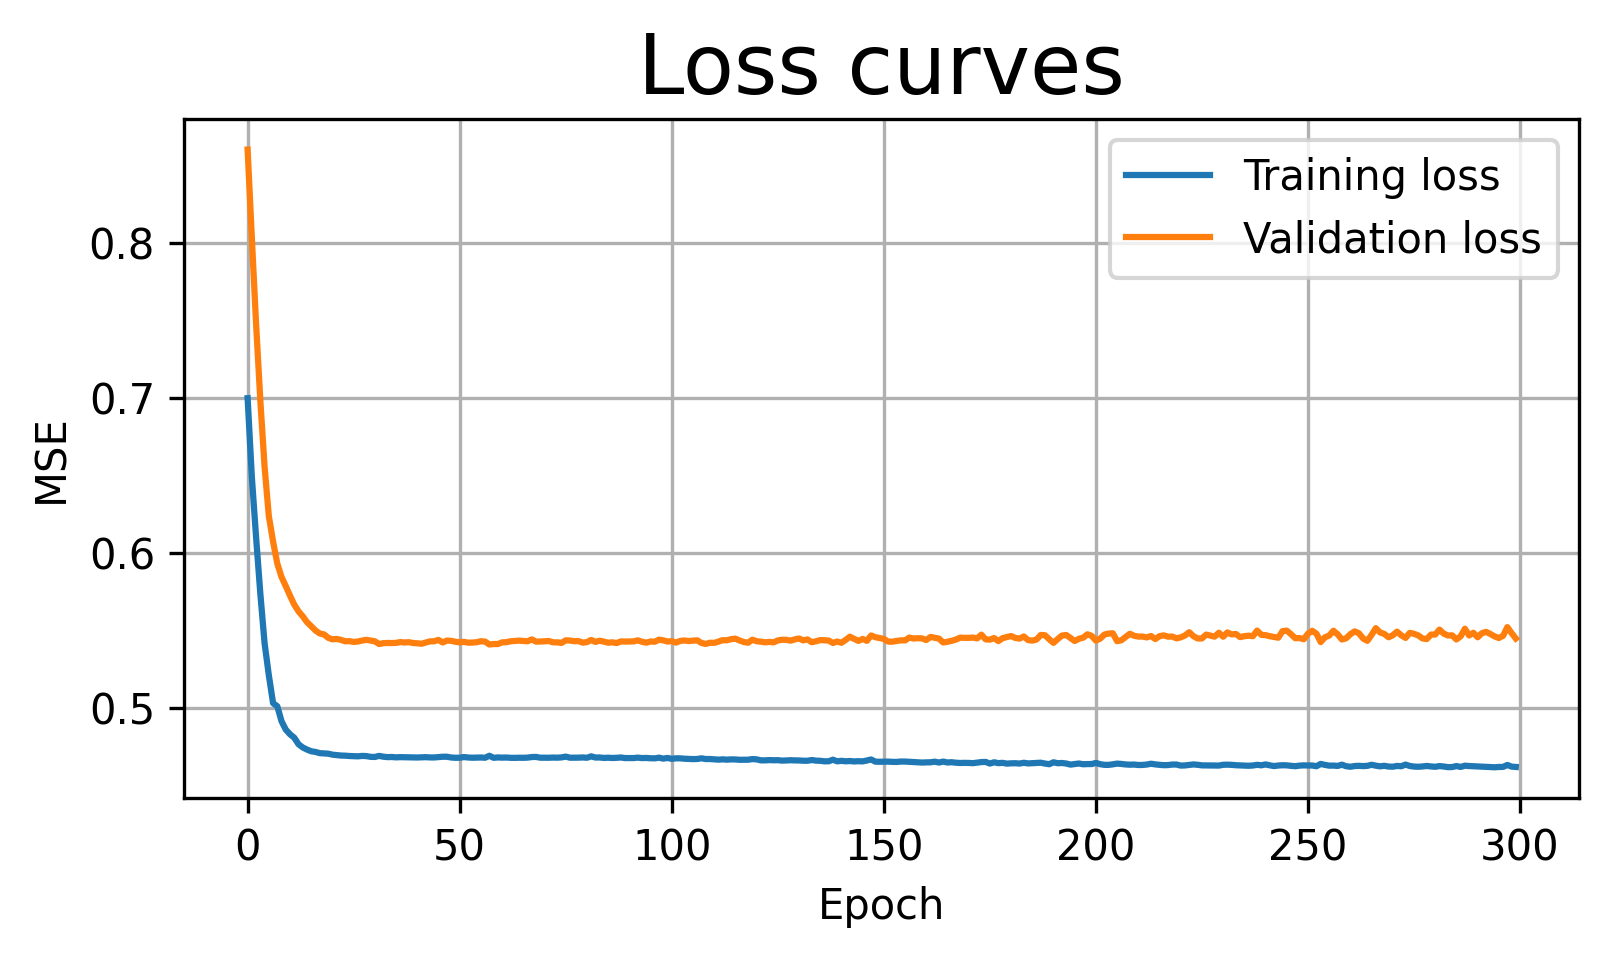

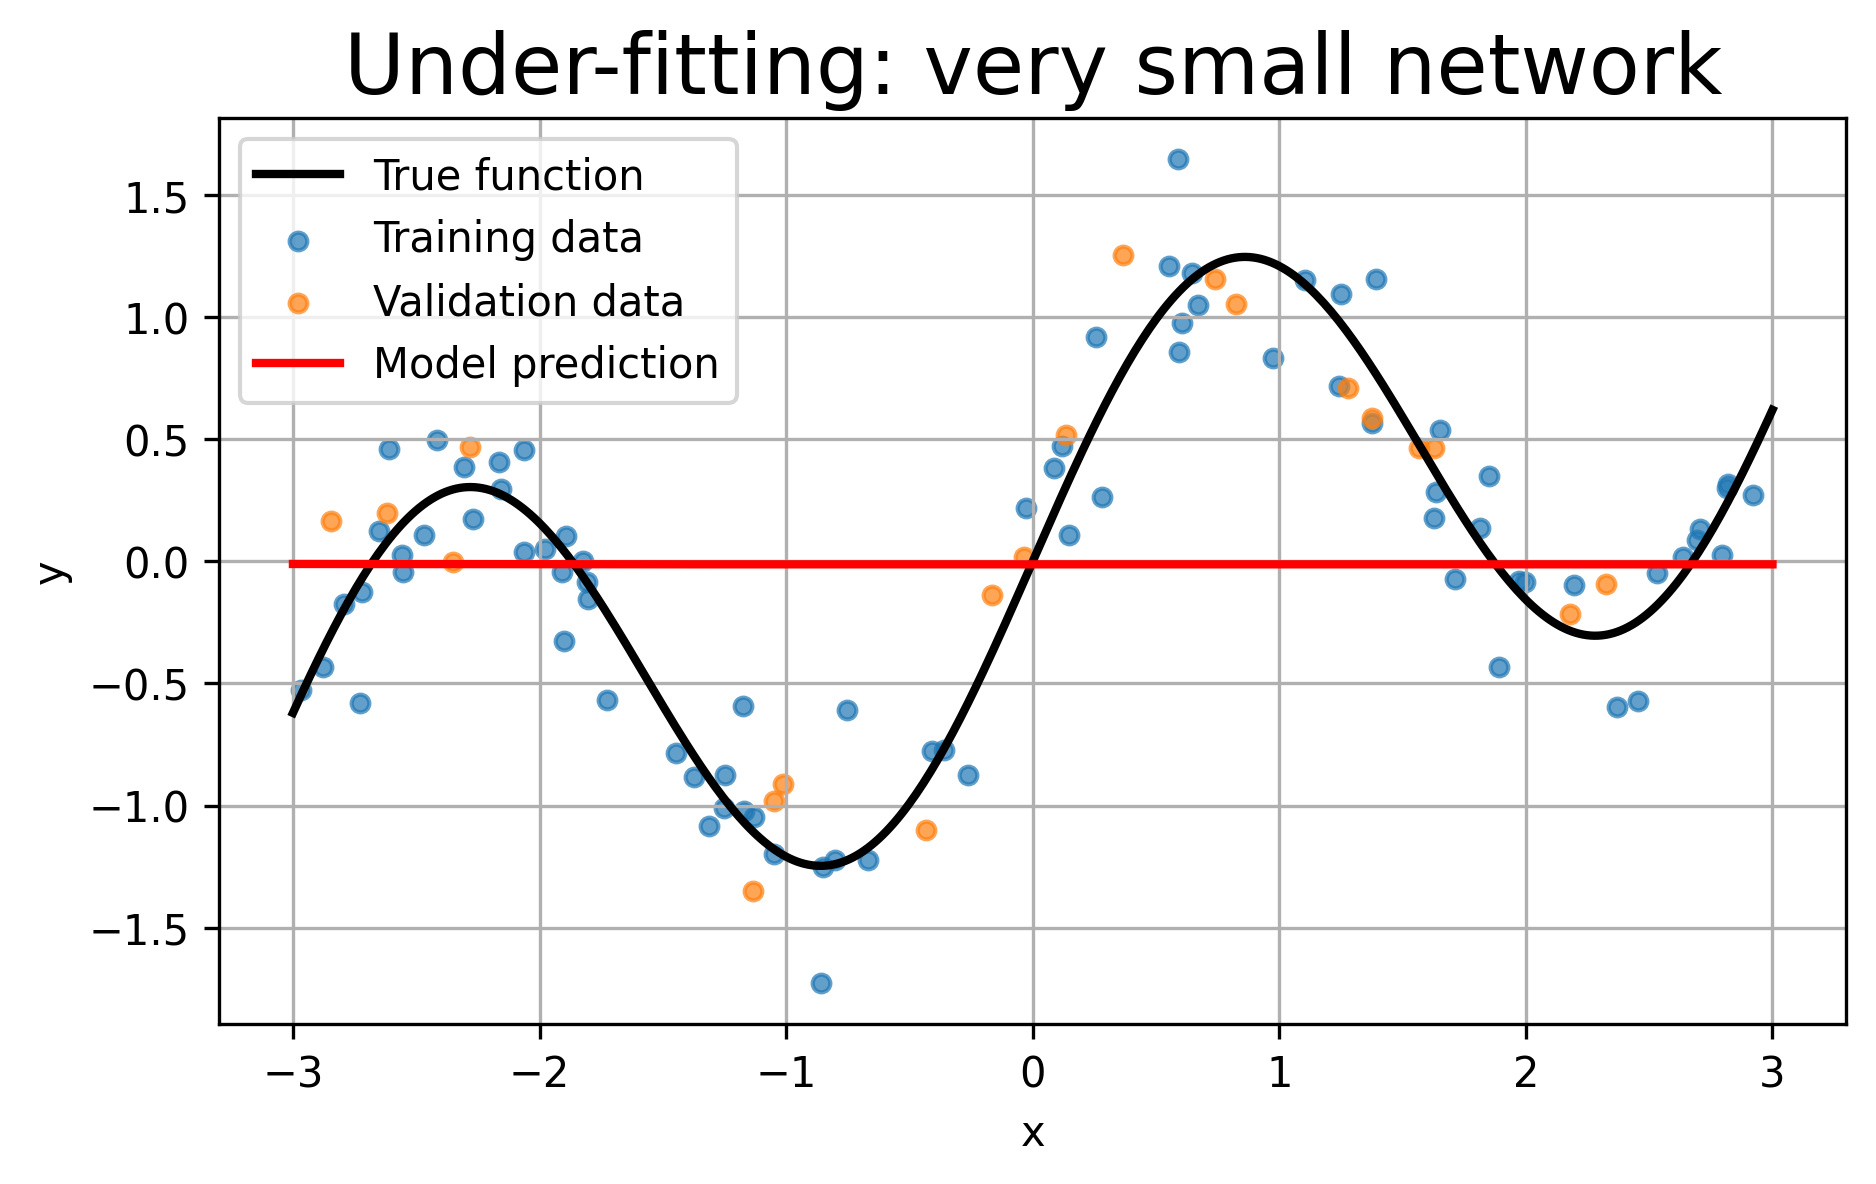

In [66]:
model_under = SimpleNet(hidden=2)

train_and_evaluate(
    model_under,
    epochs=300,
    lr=1e-2,
    early_stop=False,
    title="Under-fitting: very small network"
)


- **Observation:** The model is too simple. Both training and validation losses remain relatively high, and the prediction curve misses important parts of the true function.

##### Illustrating Over-fitting

For over-fitting, we use a much larger network and train it for many epochs. Because the data are noisy, a very flexible model may start fitting the noise rather than only the underlying trend.

Final training loss:   0.0516
Final validation loss: 0.0627
Best validation loss:  0.0383 at epoch 109


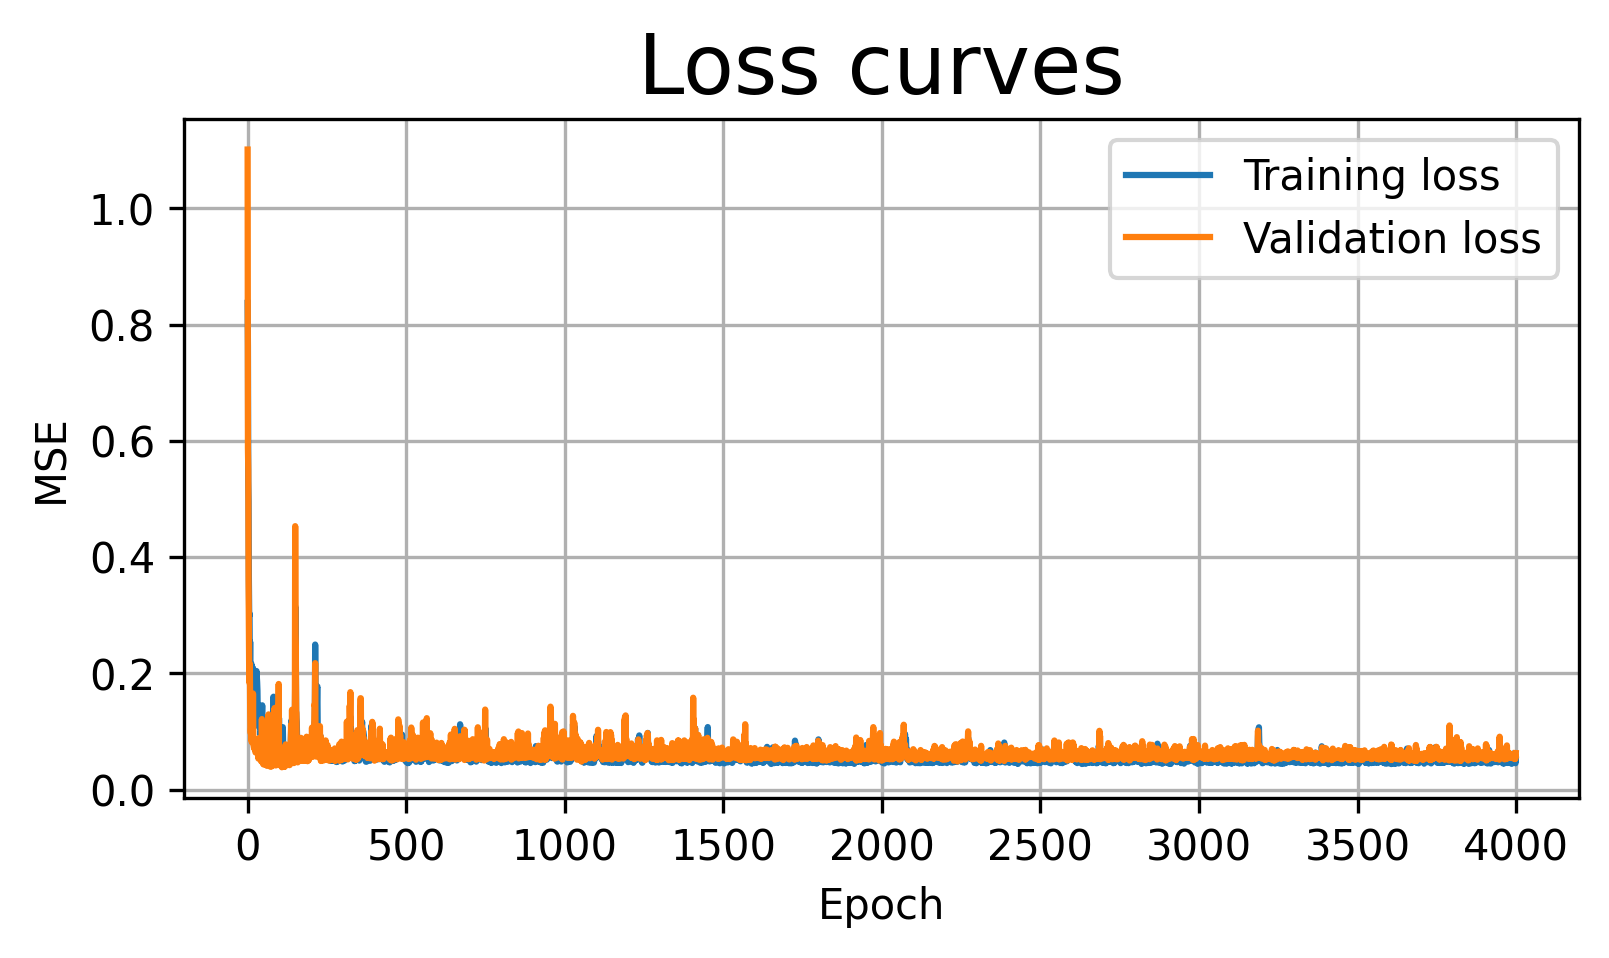

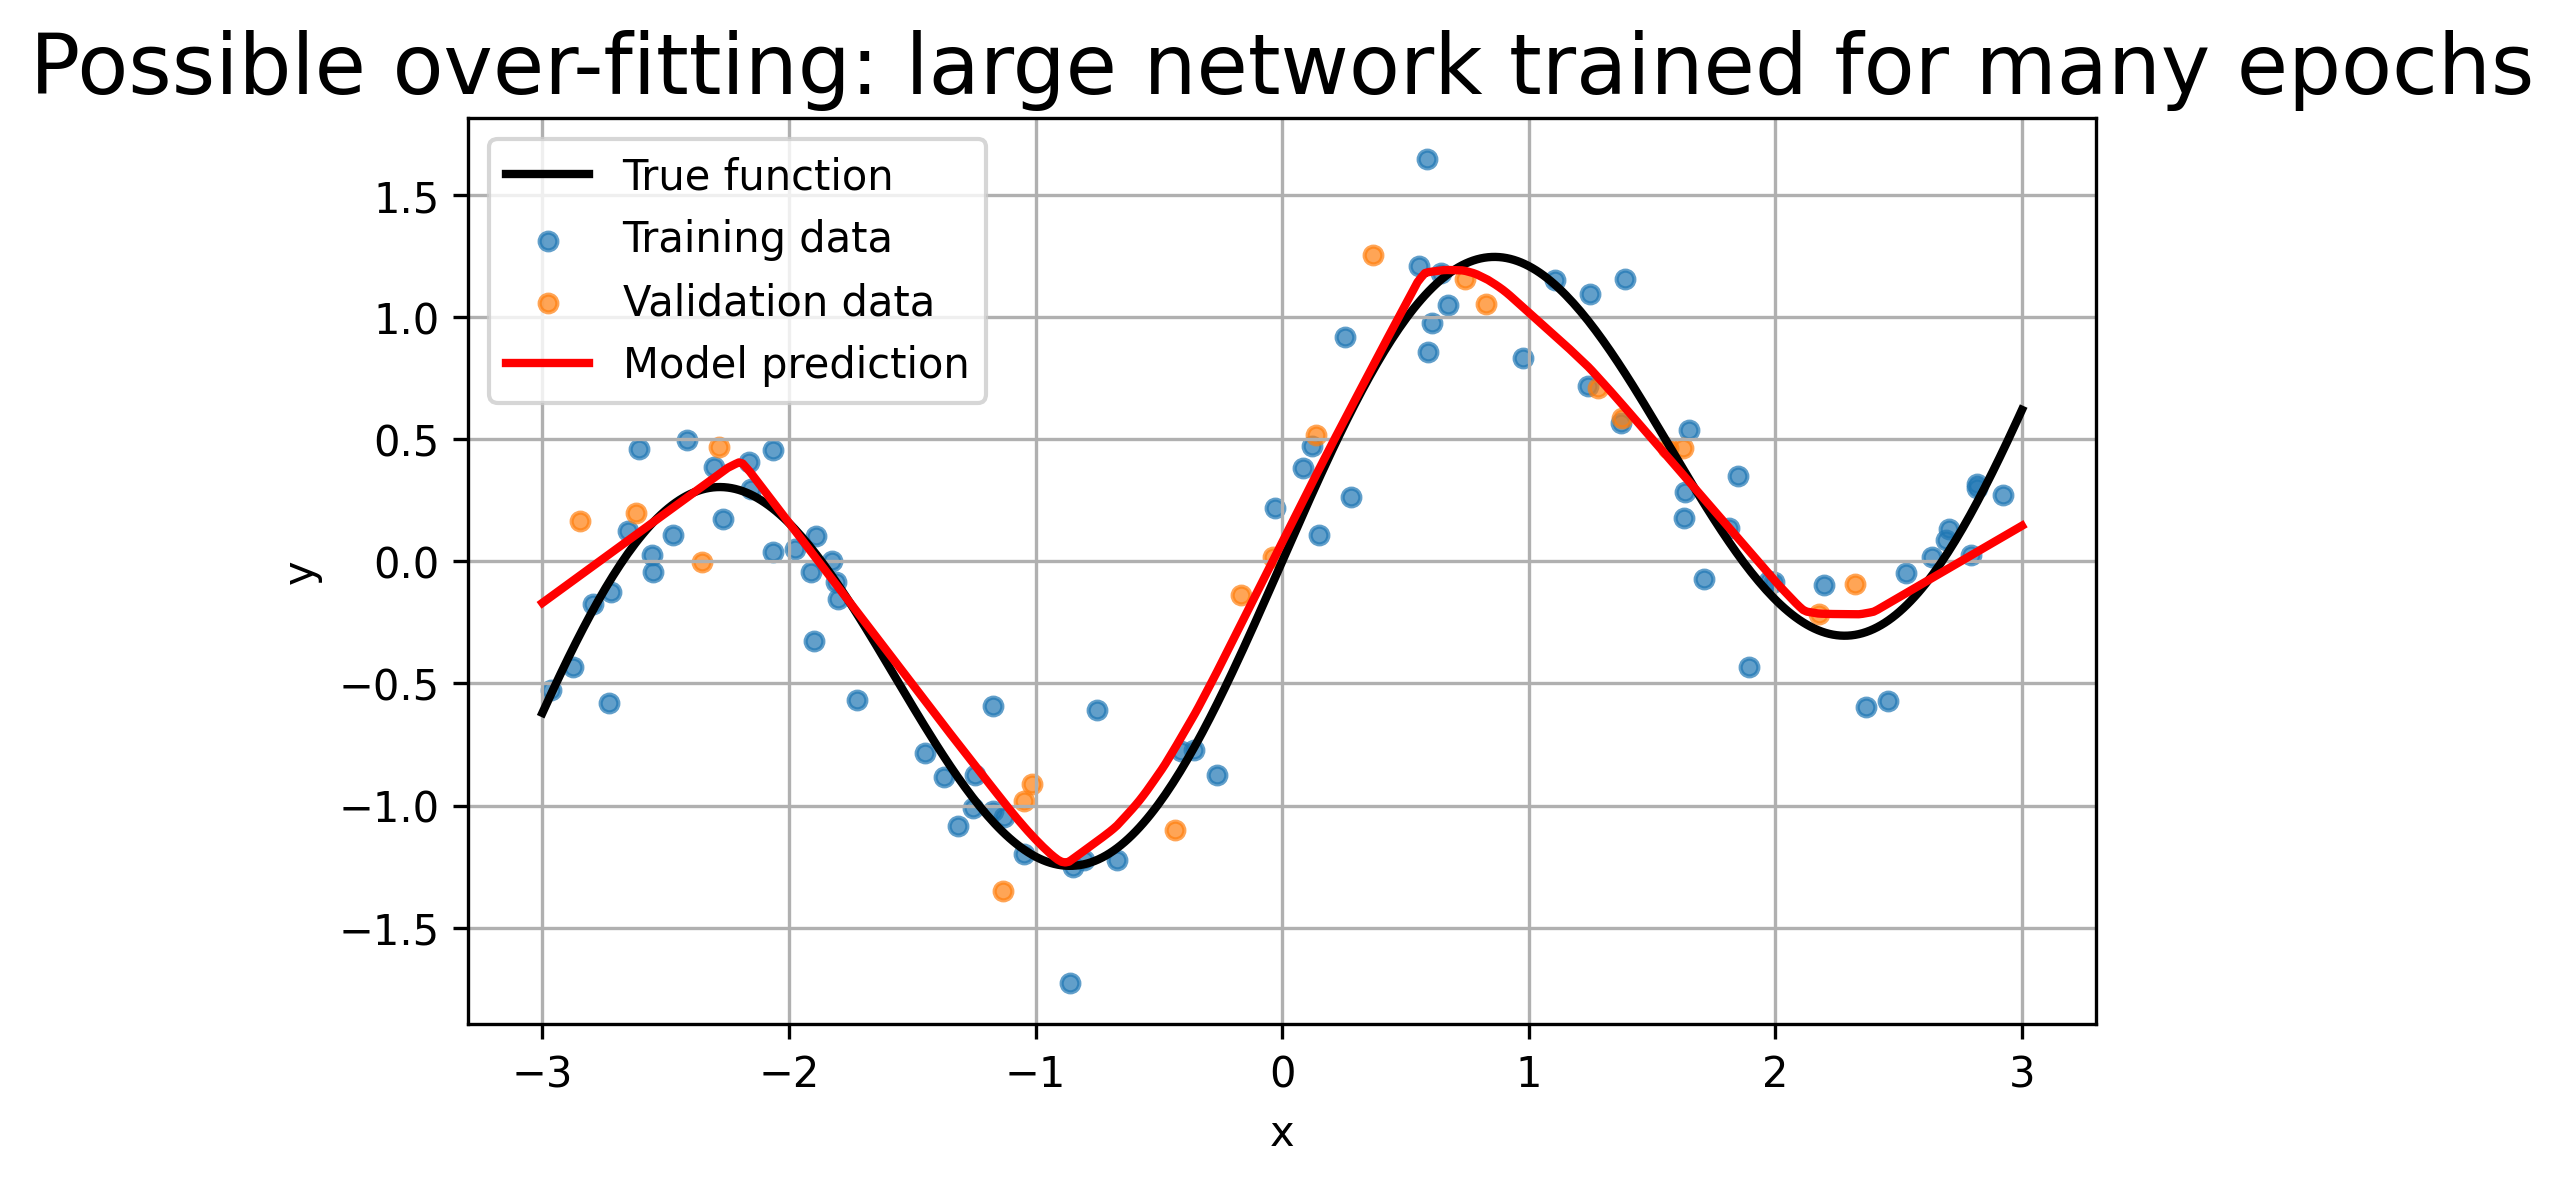

In [74]:
model_over = SimpleNet(hidden=256)

train_and_evaluate(
    model_over,
    epochs=4000,
    lr=1e-2,
    early_stop=False,
    title="Possible over-fitting: large network trained for many epochs"
)



- **Observation:** Training loss drops near zero, but the final fit oscillates wildly, chasing every noisy point. It **over-fits** the deterministic function’s high-frequency component.

#### Adding Early Stopping

Now we train the same type of large model, but we stop when the validation loss fails to improve for several epochs.

This does **not** save a model file. The best weights are kept in memory and restored at the end of training.

````{admonition} Colab note
:class: tip

If you really wanted to save the model later, you could use

```python
# torch.save(model.state_dict(), "my_model.pt")
```

but we do not execute any saving command in this notebook.

Early stopping at epoch 113. Best epoch was 63.
Final training loss:   0.0586
Final validation loss: 0.0617
Best validation loss:  0.0428 at epoch 63


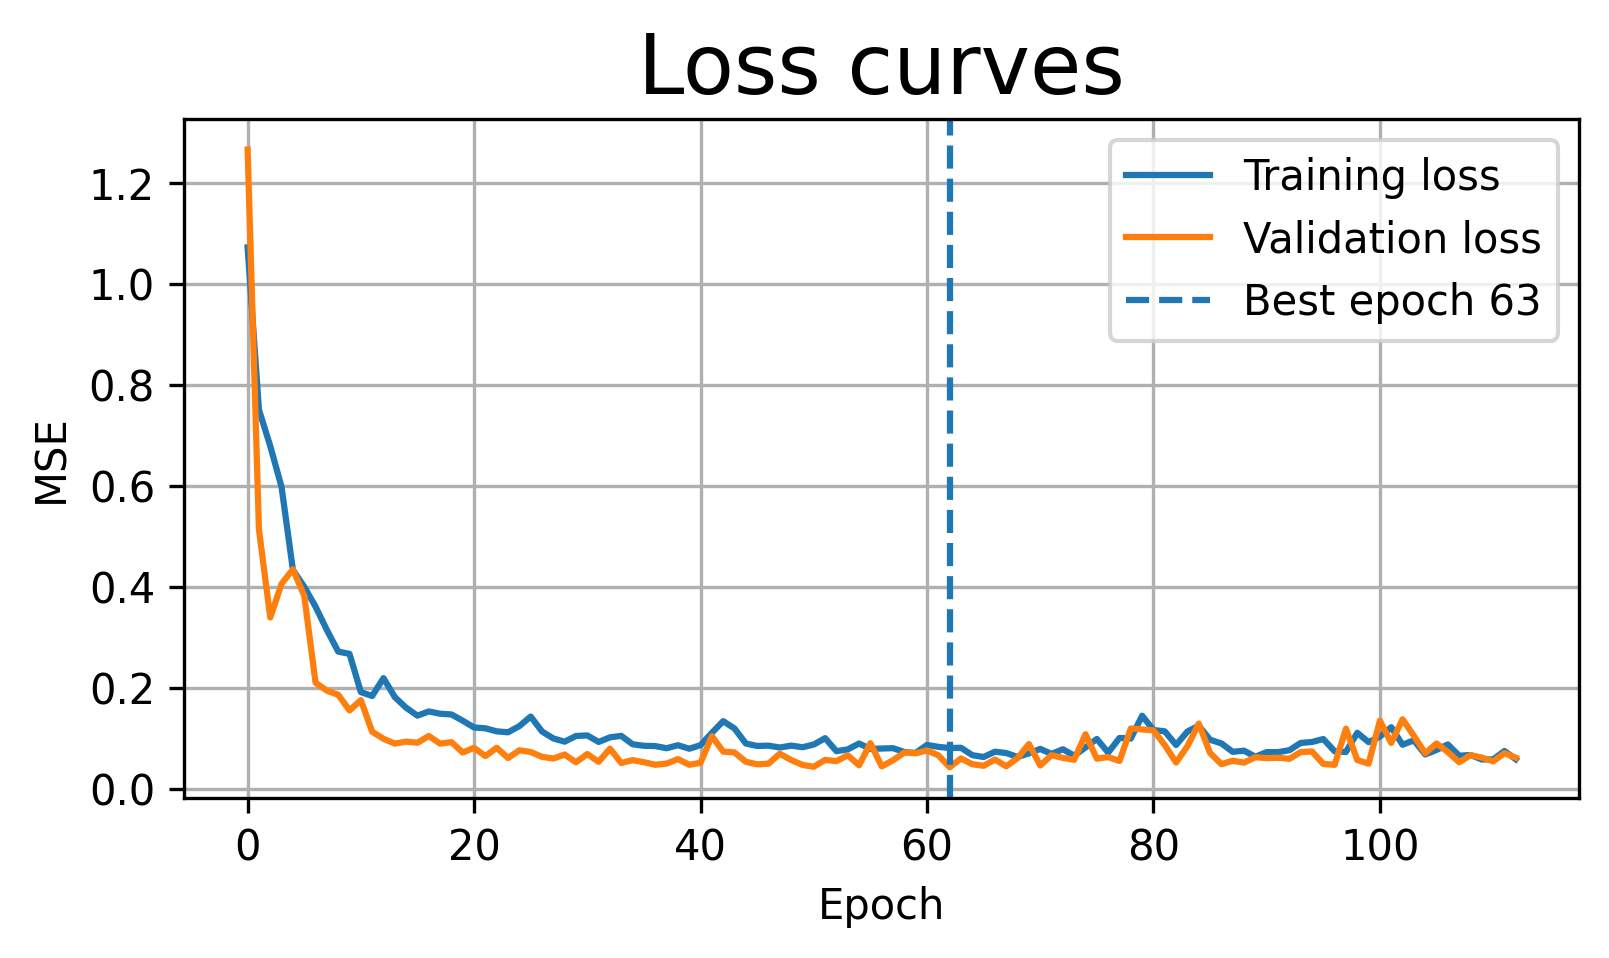

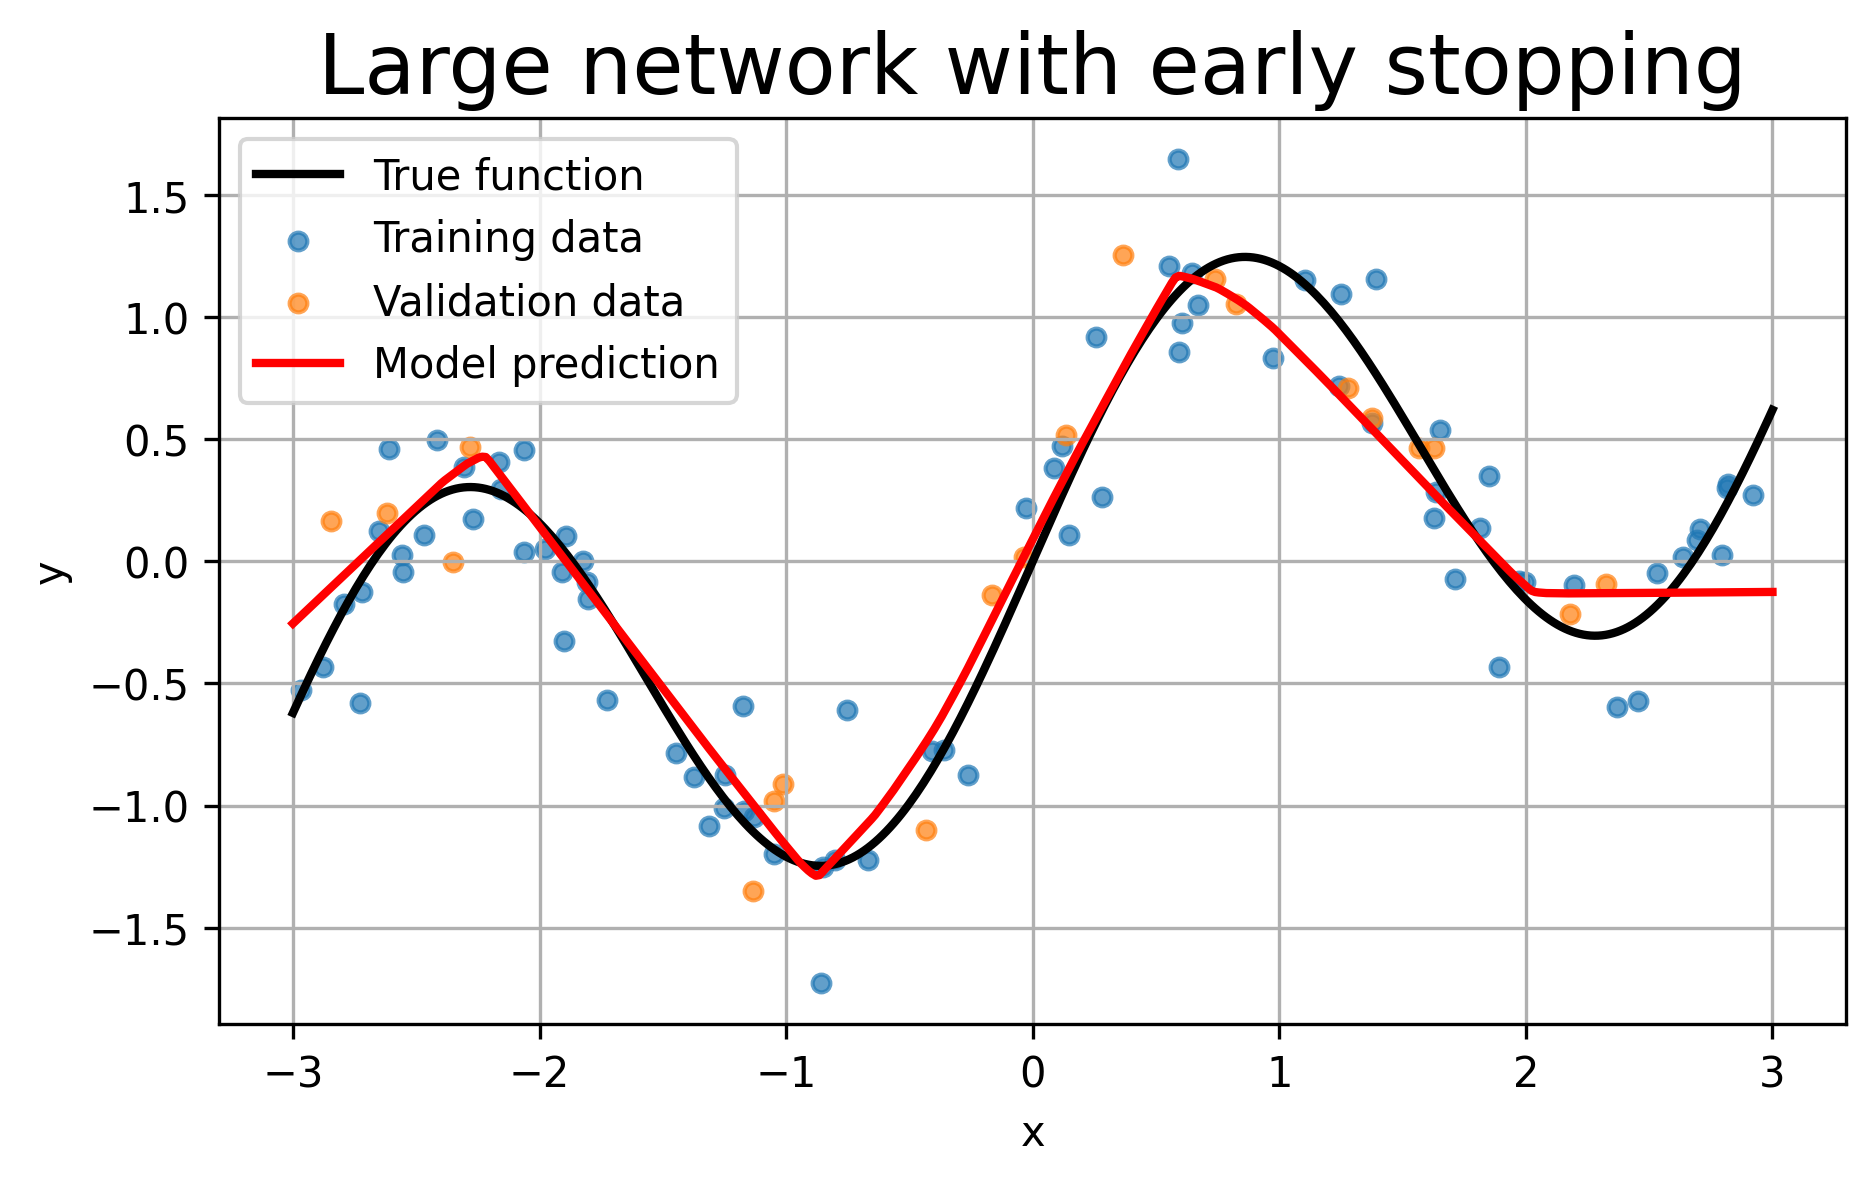

In [76]:
model_es = SimpleNet(hidden=256)

train_and_evaluate(
    model_es,
    epochs=4000,
    lr=1e-2,
    early_stop=True,
    patience=50,
    title="Large network with early stopping"
)

```{admonition} Tip: Early stopping also saves time
:class: tip

Early stopping is useful not only for controlling overfitting, but also for saving computation time.

If the validation loss has stopped improving, continuing the training for many more epochs may not help much. In that case, early stopping allows us to stop training early and keep the model from the epoch where the validation loss was best.

So early stopping is both a practical regularization trick and a computational shortcut.
```
